<a href="https://colab.research.google.com/github/Noorpr/Project-DEPI/blob/main/Copy_of_modling_depi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# "/content/resampled_15min_data.csv"
df=pd.read_csv('resampled_15min_data.csv')
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,apparent_power,power_factor,Energy_kWh,Energy_kWh_cummlative
0,16/12/2006,17:30:00,3.702,0.52,235.09,15.8,3.738342,0.990278,0.061700,0.520433
1,16/12/2006,17:45:00,7.706,0.00,230.98,33.2,7.706000,1.000000,0.128433,1.622333
2,16/12/2006,18:00:00,2.790,0.18,237.52,11.8,2.795800,0.997925,0.046500,2.580233
3,16/12/2006,18:15:00,4.598,0.10,234.25,21.4,4.599087,0.999764,0.076633,3.640633
4,16/12/2006,18:30:00,2.930,0.00,236.15,12.4,2.930000,1.000000,0.048833,4.554967


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime

# Combine Date and Time into a single datetime column
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df.set_index('datetime', inplace=True)

# Drop original columns not needed after merge
df.drop(columns=['Date', 'Time'], inplace=True)

# Ensure numeric types
df = df.apply(pd.to_numeric, errors='coerce')

# Drop NaNs (or interpolate)
df.interpolate(inplace=True)


In [4]:
# Add time-based features
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month

# Lag features (e.g., previous timestep power factor)
df['pf_lag1'] = df['power_factor'].shift(1)
df['pf_lag96'] = df['power_factor'].shift(96)  # same time yesterday

# Rolling statistics
df['pf_rolling_mean_96'] = df['power_factor'].rolling(96).mean()
df['pf_rolling_std_96'] = df['power_factor'].rolling(96).std()

df.dropna(inplace=True)  # Drop NaNs from lags and rolling



In [5]:
# Select features and target
features = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity',
            'hour', 'dayofweek', 'month', 'pf_lag1', 'pf_lag96', 'pf_rolling_mean_96', 'pf_rolling_std_96']
target = 'power_factor'

data = df[features + [target]]

# Normalize
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Convert back to DataFrame
data_scaled = pd.DataFrame(data_scaled, columns=features + [target], index=df.index)


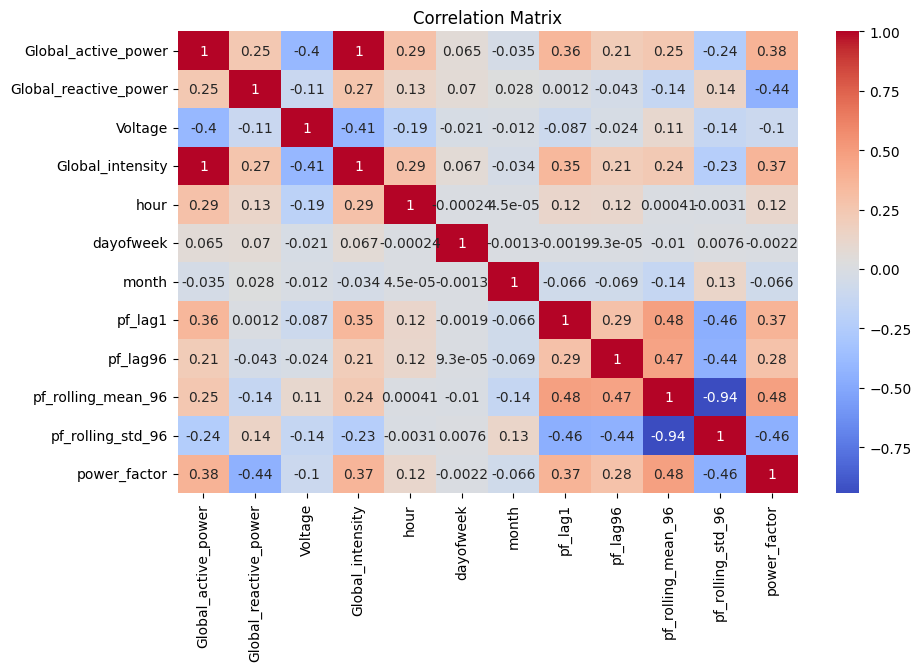

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap of correlations
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [7]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1])  # all features
        y.append(data[i:i+seq_length, -1])   # power factor only
    return np.array(X), np.array(y)

SEQ_LEN = 96  # one day of 15-min intervals
X, y = create_sequences(data_scaled.values, SEQ_LEN)

# Train/test split
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]


In [19]:
# get 96 samples from the X_test data
X_test_96 = X_test[192:288]

result = X_test_96[0]
result = pd.DataFrame(result, columns=features)
result.to_csv('third_sample.csv')

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, TimeDistributed

model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.2))
model.add(TimeDistributed(Dense(1)))

model.compile(optimizer='adam', loss='mse')
model.summary()

# Training
history = model.fit(X_train, y_train, epochs=10, batch_size=64,
                    validation_split=0.1, shuffle=False)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 96, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 96, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 96, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,545 (205.25 KB)

 Trainable params: 52,545 (205.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 31s 208ms/step - loss: 0.1422 - val_loss: 0.0367
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 22s 197ms/step - loss: 0.0536 - val_loss: 0.0305
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 43s 211ms/step - loss: 0.0376 - val_loss: 0.0272
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 41s 211ms/step - loss: 0.0336 - val_loss: 0.0251
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 22s 197ms/step - loss: 0.0304 - val_loss: 0.0233
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 42s 204ms/step - loss: 0.0279 - val_loss: 0.0215
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 42s 215ms/step - loss: 0.0253 - val_loss: 0.0187
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 41s 216ms/step - loss: 0.0225 - val_loss: 0.0159
Epoch 9/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 38s 185ms/step - loss: 0.0204 - val_loss: 0.0143
Epoch 10/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 41s 189ms/step - loss: 0.0191 - val_loss: 0.0130


Epoch 1/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - loss: 0.0178
Epoch 1: val_loss improved from inf to 0.01064, saving model to best_model.h5


112/112 ━━━━━━━━━━━━━━━━━━━━ 23s 203ms/step - loss: 0.0178 - val_loss: 0.0106
Epoch 2/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 0.0161
Epoch 2: val_loss improved from 0.01064 to 0.00837, saving model to best_model.h5


112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 180ms/step - loss: 0.0161 - val_loss: 0.0084
Epoch 3/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - loss: 0.0139
Epoch 3: val_loss improved from 0.00837 to 0.00714, saving model to best_model.h5


112/112 ━━━━━━━━━━━━━━━━━━━━ 22s 192ms/step - loss: 0.0139 - val_loss: 0.0071
Epoch 4/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - loss: 0.0119
Epoch 4: val_loss improved from 0.00714 to 0.00590, saving model to best_model.h5


112/112 ━━━━━━━━━━━━━━━━━━━━ 41s 193ms/step - loss: 0.0119 - val_loss: 0.0059
Epoch 5/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - loss: 0.0105
Epoch 5: val_loss improved from 0.00590 to 0.00465, saving model to best_model.h5


...

112/112 ━━━━━━━━━━━━━━━━━━━━ 41s 194ms/step - loss: 0.0015 - val_loss: 2.2290e-04
Epoch 41/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - loss: 0.0014
Epoch 41: val_loss improved from 0.00022 to 0.00022, saving model to best_model.h5


112/112 ━━━━━━━━━━━━━━━━━━━━ 42s 200ms/step - loss: 0.0014 - val_loss: 2.1884e-04
Epoch 42/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - loss: 0.0014
Epoch 42: val_loss improved from 0.00022 to 0.00021, saving model to best_model.h5


112/112 ━━━━━━━━━━━━━━━━━━━━ 41s 197ms/step - loss: 0.0014 - val_loss: 2.0973e-04
Epoch 43/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - loss: 0.0013
Epoch 43: val_loss improved from 0.00021 to 0.00020, saving model to best_model.h5


112/112 ━━━━━━━━━━━━━━━━━━━━ 41s 196ms/step - loss: 0.0013 - val_loss: 1.9772e-04
Epoch 44/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.0013
Epoch 44: val_loss improved from 0.00020 to 0.00019, saving model to best_model.h5


112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 181ms/step - loss: 0.0013 - val_loss: 1.8828e-04
Epoch 45/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - loss: 0.0012
Epoch 45: val_loss did not improve from 0.00019
112/112 ━━━━━━━━━━━━━━━━━━━━ 22s 195ms/step - loss: 0.0012 - val_loss: 1.8942e-04
Epoch 46/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.0012
Epoch 46: val_loss did not improve from 0.00019
112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 181ms/step - loss: 0.0012 - val_loss: 1.8889e-04
Epoch 47/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - loss: 0.0012
Epoch 47: val_loss did not improve from 0.00019
112/112 ━━━━━━━━━━━━━━━━━━━━ 22s 197ms/step - loss: 0.0012 - val_loss: 2.3770e-04
Epoch 48/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - loss: 0.0012
Epoch 48: val_loss did not improve from 0.00019
112/112 ━━━━━━━━━━━━━━━━━━━━ 41s 195ms/step - loss: 0.0012 - val_loss: 1.9787e-04
Epoch 49/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 0.0015
Epoch 49: val_loss did not improve from 0.00019


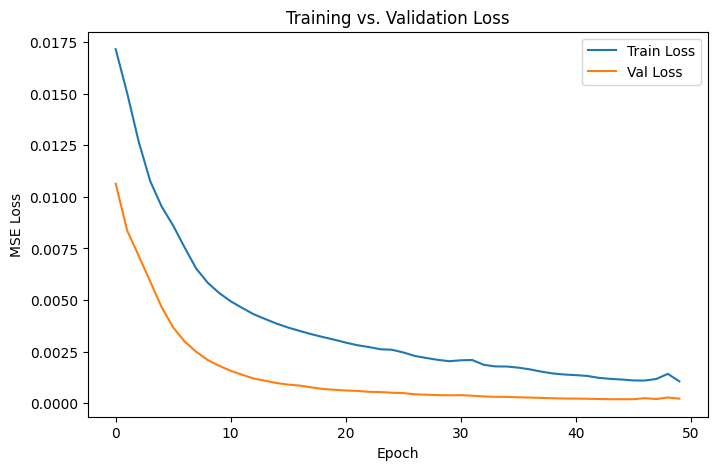

👉 Best epoch: 44, Validation Loss: 0.00019
✅ Loaded best weights from epoch 44


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint

# 1. Set up a ModelCheckpoint to save best weights only
checkpoint_cb = ModelCheckpoint(
    'best_model.h5',           # filepath to save
    monitor='val_loss',        # quantity to monitor
    save_best_only=True,       # only save when val_loss improves
    mode='min',                # 'min' because lower val_loss is better
    verbose=1
)

# 2. Fit your model with the checkpoint callback
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    shuffle=False,
    callbacks=[checkpoint_cb]
)

# 3. Plot training & validation loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],    label='Train Loss')
plt.plot(history.history['val_loss'],label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.show()

# 4. Find the best epoch
val_losses = np.array(history.history['val_loss'])
best_epoch = val_losses.argmin() + 1
best_val_loss = val_losses.min()
print(f"👉 Best epoch: {best_epoch}, Validation Loss: {best_val_loss:.5f}")

# 5. Load the best weights back into the model
model.load_weights('best_model.h5')
print("✅ Loaded best weights from epoch", best_epoch)


62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step


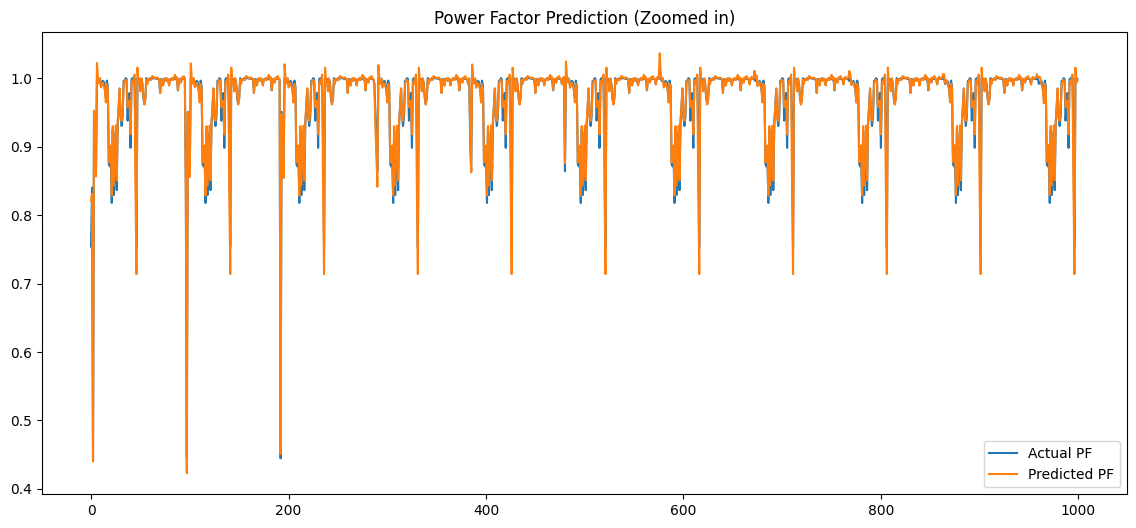

MAE: 0.0085
MSE: 0.0002


In [12]:

y_pred = model.predict(X_test)

# Rescale predictions
y_test_flat = y_test.flatten()
y_pred_flat = y_pred.flatten()

# Plot actual vs predicted
plt.figure(figsize=(14, 6))
plt.plot(y_test_flat[:1000], label='Actual PF')
plt.plot(y_pred_flat[:1000], label='Predicted PF')
plt.title('Power Factor Prediction (Zoomed in)')
plt.legend()
plt.show()

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
print(f"MAE: {mean_absolute_error(y_test_flat, y_pred_flat):.4f}")
print(f"MSE: {mean_squared_error(y_test_flat, y_pred_flat):.4f}")


In [15]:
# 1) لحفظ بصيغة HDF5:
model.save('powerfactor_model.h5')
# → يحفظ كلا البنية والأوزان في ملف .h5

